# AI Replacing Tech Jobs for Humans: So What's Now?
### A step-by-step implementation of the flowchart model with US data (2022–2026)

This notebook turns the handwritten model into code. It follows the flowchart one box at a time:

```
Firm AI adoption ──► Task displacement to AI ──► Junior–mid tech worker displacement
      │                                                   │
      ▼                                                   ▼
Token cost increase                             Buffer phase: look for a job of the same type
      │                                           (spending stays more or less the same)
      ▼                                                   │
More cost minimization                                    ▼
      │                                         Savings fall to almost 0 by T₀
      ▼                                                   │
More employee termination ───────────┐                    ▼
      │                              └──(+)──► Switch to a lower-paying job / leave tech
      ▼                                                   │
Fewer tech job options ───────────────────────────────────┤
                                                          ▼
          Fewer consumers, less income for other industries (organic food, clothing, even healthcare)
```

| Step | Flowchart box | Model equation (from the notes) | Dataset |
|---|---|---|---|
| 0 | – | – | load and clean all series |
| 1 | Firm AI adoption → token cost | $c_A = p_T\,q$ | `lowest_price_models_data.csv` |
| 2 | Task production | $Y=\left(\int_{N-1}^{N} y_i^{\frac{\sigma-1}{\sigma}}di\right)^{\frac{\sigma}{\sigma-1}}$ | – (theory) |
| 3 | Task displacement to AI | $e(i)=W/\gamma(i)$, $\gamma(\bar I)=W/c_A$, $I^*=\min\{I,\bar I\}$ | token prices + wages |
| 4 | Junior–mid tech displacement | $L=YW^{-\sigma}\int_{I^*}^{N}\gamma(i)^{\sigma-1}di$, $L=\frac{x}{c_A+e_s}\cdot\frac{1}{g_s}$, $S_W=WL/x$ | `CES6054150001.csv` (tech employment) |
| 5 | Buffer phase / savings → 0 | $m(\tau)=s_rW+(z-\bar c)\tau$, $T_0=\frac{s_rW}{\bar c-z}$ | `PSAVERT.csv`, `LNU05026642.csv`, `PCE.csv`, `CPIAUCSL.csv` |
| 6 | Switch to a lower-paying job | $\Delta C_{fired}=-c_L L_{disp}(W_{Tech}-W_{Service})$ | tech employment |
| 7 | National economy | $S_L=Y_L/Y$, $S_K=Y_K/Y$, $C=Y(c_LS_L+c_KS_K)$ | `PCE.csv` |
| 8 | Fewer consumers → other industries | $\Delta C=(c_L-c_K)\Delta Y_L+c_K\Delta Y$, $\Delta AD=\frac{1}{1-c_L}\Delta C$ | – |
| 9 | Token-cost feedback loop | dynamic simulation of every box together | all |

> **Read this first.** The datasets have no wage, GDP or token-per-task figures, so a few parameters are **assumptions**. They are all in one cell (Step 0.2) so you can change them and re-run.

## Step 0: Setup and data

### 0.1 Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import integrate, optimize
from pathlib import Path

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Chart style: thin lines, light grid, a fixed colour order (blue, orange, aqua)
BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#52514e"
plt.rcParams.update({
    "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c2", "axes.labelcolor": INK, "axes.titleweight": "bold",
    "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.8,
    "xtick.color": INK, "ytick.color": INK, "lines.linewidth": 2,
    "legend.frameon": False,
})
DATA = Path("data") if Path("data").exists() else Path(".")   # CSVs in data/ or next to the notebook

### 0.2 Model parameters (assumptions)

These are the only numbers that do not come from the CSV files. Each has a short reason.

In [2]:
P = dict(
    # --- wages (monthly, USD) -------------------------------------------------
    W_tech    = 10_400,   # ≈ $60/h × 173 h, typical computer-systems-design pay (BLS OES)
    W_service = 3_800,    # ≈ $22/h × 173 h, typical service / non-tech job
    hours     = 173,      # working hours per month

    # --- AI side ----------------------------------------------------------------
    q_tokens  = 1_000_000,  # q: tokens needed for 1 task unit (≈ 1 junior-dev hour of agentic work)
    sigma     = 0.8,        # σ: elasticity of substitution between tasks (<1 = complements)
    k_gamma   = np.log(50), # γ(i)=exp(k·i): the hardest task is 50× more labour-productive than the easiest

    # --- households -------------------------------------------------------------
    z         = 2_000,    # z: income while searching (UI benefits, severance, freelancing), $/month
    save_months = 60,     # months (≈5 years) over which the pre-fire saving rate built the buffer
                          # (set to 1 to get the literal m(0) = s_r·W from the notes)
    c_L       = 0.80,     # marginal propensity to consume out of labour income
    c_K       = 0.30,     # marginal propensity to consume out of capital / token income
    labour_share0 = 0.60, # initial labour share of national income (S_L)
    pce_share = 0.68,     # PCE / national income, used to scale national income from PCE

    # --- exposure --------------------------------------------------------------
    exposed_share = 0.40, # share of tech employment in junior–mid roles that AI can take
)
P

{'W_tech': 10400,
 'W_service': 3800,
 'hours': 173,
 'q_tokens': 1000000,
 'sigma': 0.8,
 'k_gamma': 3.912023005428146,
 'z': 2000,
 'save_months': 60,
 'c_L': 0.8,
 'c_K': 0.3,
 'labour_share0': 0.6,
 'pce_share': 0.68,
 'exposed_share': 0.4}

### 0.3 Load the six datasets

| File | Series | Unit | Role in the model |
|---|---|---|---|
| `CES6054150001` | All employees, computer systems design & related services | thousands | tech employment $L_{Tech}$ |
| `LNU05026642` | Not in labor force, searched for work and available | thousands | people stuck in the buffer / search phase |
| `PSAVERT` | Personal saving rate | % | $s_r$ |
| `PCE` | Personal consumption expenditures | $bn, annual rate | consumption $C$ |
| `CPIAUCSL` | Consumer price index | index | deflator (real values) |
| `lowest_price_models_data` | cheapest model reaching a benchmark score, over time | $ per 1M tokens | token price $p_T$ |

In [3]:
def load_fred(name):
    s = pd.read_csv(DATA / f"{name}.csv", parse_dates=["observation_date"], index_col="observation_date")[name]
    return s.astype(float)

macro = pd.concat({
    "tech_emp":  load_fred("CES6054150001"),
    "searching": load_fred("LNU05026642"),
    "save_rate": load_fred("PSAVERT"),
    "pce":       load_fred("PCE"),
    "cpi":       load_fred("CPIAUCSL"),
}, axis=1)
macro.index.name = "date"

print("Missing values per series:\n", macro.isna().sum())
macro[macro.isna().any(axis=1)]

Missing values per series:
 tech_emp     0
searching    1
save_rate    1
pce          1
cpi          1
dtype: int64


,tech_emp,searching,save_rate,pce,cpi
date,,,,,
2025-10-01,"2,379.700",NaN,3.900,"21,288.100",NaN
2026-08-01,"2,362.700","1,655.000",NaN,NaN,334.131


**Cleaning.** October 2025 is missing for CPI and the job-search series (the 2025 US government shutdown stopped data collection). We fill it by linear interpolation between September and November. The last month (August 2026) has no PCE or saving rate yet, so any step that needs those uses data up to July 2026.

In [4]:
macro[["cpi", "searching"]] = macro[["cpi", "searching"]].interpolate(limit_area="inside")

# Real consumption in constant Jan-2022 dollars
macro["real_pce"] = macro["pce"] / (macro["cpi"] / macro["cpi"].iloc[0])
macro["inflation_yoy"] = macro["cpi"].pct_change(12) * 100
macro.tail()

,tech_emp,searching,save_rate,pce,cpi,real_pce,inflation_yoy
date,,,,,,,
2026-04-01,"2,369.500","1,732.000",2.900,"21,949.500",332.407,"18,656.880",3.779
2026-05-01,"2,370.000","1,637.000",2.800,"22,136.800",333.979,"18,727.518",4.167
2026-06-01,"2,368.300","1,825.000",2.600,"22,214.200",332.568,"18,872.732",3.464
2026-07-01,"2,363.600","1,871.000",3.000,"22,250.400",332.813,"18,889.571",3.304
2026-08-01,"2,362.700","1,655.000",NaN,NaN,334.131,NaN,3.353


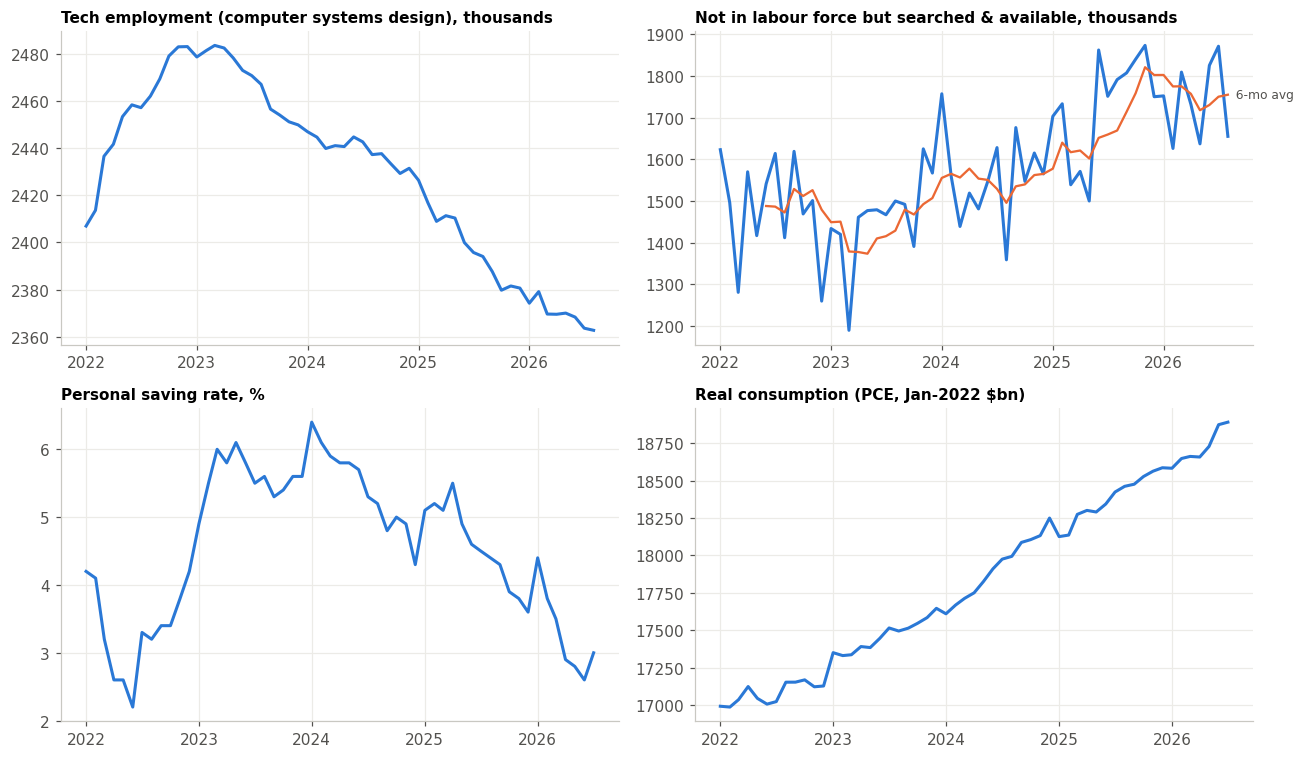

Tech employment peak: 2,483.5k in Mar 2023; latest 2,362.7k (-4.9%)
Saving rate: 6.4% (peak) → 3.0% (latest)


In [5]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
panels = [("tech_emp", "Tech employment (computer systems design), thousands"),
          ("searching", "Not in labour force but searched & available, thousands"),
          ("save_rate", "Personal saving rate, %"),
          ("real_pce", "Real consumption (PCE, Jan-2022 $bn)")]
for a, (col, title) in zip(ax.flat, panels):
    a.plot(macro.index, macro[col], color=BLUE)
    a.set_title(title, fontsize=10, loc="left")
    a.xaxis.set_major_locator(mdates.YearLocator()); a.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax[0, 1].plot(macro.index, macro["searching"].rolling(6).mean(), color=ORANGE, lw=1.5)
ax[0, 1].text(macro.index[-1], macro["searching"].rolling(6).mean().iloc[-1], "  6-mo avg",
              color=INK, fontsize=8, va="center")
plt.tight_layout(); plt.show()

peak_date = macro["tech_emp"].idxmax()
print(f"Tech employment peak: {macro['tech_emp'].max():,.1f}k in {peak_date:%b %Y}; "
      f"latest {macro['tech_emp'].iloc[-1]:,.1f}k "
      f"({macro['tech_emp'].iloc[-1] / macro['tech_emp'].max() - 1:.1%})")
print(f"Saving rate: {macro['save_rate'].max():.1f}% (peak) → {macro['save_rate'].dropna().iloc[-1]:.1f}% (latest)")

**What the raw data already says.** Tech employment peaked in early 2023 and has fallen almost every month since. The number of people searching for work outside the labour force has risen. The saving rate is back near 2022 lows. These are the three facts the flowchart predicts. The remaining steps check whether the model's mechanism can produce them.

---
## Step 1: Firm AI adoption → token cost  ($c_A = p_T \cdot q$)

From the notes: *for AI, 1 unit of task needs $q$ tokens priced at $p_T$ per token, so the AI cost per unit of task output is*

$$c_A = p_T \, q$$

- $p_T$ = price of a token (from the dataset)
- $q$ = tokens needed to do one unit of task (assumption, `q_tokens`)

The dataset tracks, for a fixed capability level (e.g. "at least GPT-4 on MMLU"), the **cheapest model** that reaches it over time. We estimate how fast that price falls with a log-linear regression that has a fixed effect for each capability threshold:

$$\ln p_{T,jt} = \alpha_j + \beta \cdot t + \varepsilon_{jt}$$

In [6]:
tok = pd.read_csv(DATA / "lowest_price_models_data.csv", parse_dates=["Release Date"])
tok["group"] = tok["Benchmark"] + " | " + tok["Threshold model"]
tok["years"] = (tok["Release Date"] - pd.Timestamp("2022-01-01")).dt.days / 365.25
tok["log_p"] = np.log(tok["USD per 1M Tokens"])
print(f"{len(tok)} observations, {tok['group'].nunique()} capability thresholds, "
      f"{tok['Release Date'].min():%Y-%m} to {tok['Release Date'].max():%Y-%m}")

# Fixed-effects OLS: demean within each capability group
d = tok.assign(y=tok.log_p - tok.groupby("group").log_p.transform("mean"),
               x=tok.years - tok.groupby("group").years.transform("mean"))
beta = (d.x * d.y).sum() / (d.x ** 2).sum()
resid = d.y - beta * d.x
se = np.sqrt((resid ** 2).sum() / (len(d) - tok.group.nunique() - 1) / (d.x ** 2).sum())
annual_factor = np.exp(beta)
print(f"β = {beta:.3f} per year (s.e. {se:.3f})")
print(f"→ the price of a fixed capability level is multiplied by {annual_factor:.3f} each year "
      f"(≈ {1/annual_factor:.0f}× cheaper per year)")

119 observations, 21 capability thresholds, 2021-11 to 2025-02
β = -3.184 per year (s.e. 0.172)
→ the price of a fixed capability level is multiplied by 0.041 each year (≈ 24× cheaper per year)


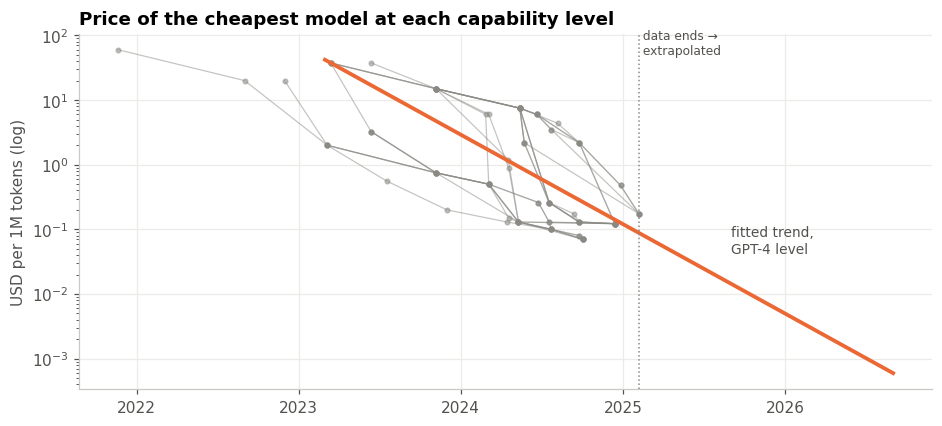

In [7]:
fig, ax = plt.subplots()
for g, sub in tok.groupby("group"):
    ax.plot(sub["Release Date"], sub["USD per 1M Tokens"], color=GRAY, lw=0.8, alpha=0.5, marker="o", ms=3)
# GPT-4 level anchor and fitted trend
anchor = tok.query("`Model Name`=='GPT-4-0314'")["USD per 1M Tokens"].iloc[0]   # $37.5 in Mar-2023
t_grid = pd.date_range("2023-03-01", "2026-09-01", freq="MS")
yrs = (t_grid - pd.Timestamp("2023-03-14")).days / 365.25
ax.plot(t_grid, anchor * annual_factor ** yrs, color=ORANGE, lw=2.5)
ax.text(t_grid[30], anchor * annual_factor ** yrs[30] * 3, "fitted trend,\nGPT-4 level", color=INK, fontsize=9)
ax.axvline(tok["Release Date"].max(), color=GRAY, ls=":", lw=1)
ax.text(tok["Release Date"].max(), 50, " data ends →\n extrapolated", fontsize=8, color=INK)
ax.set_yscale("log"); ax.set_ylabel("USD per 1M tokens (log)")
ax.set_title("Price of the cheapest model at each capability level", loc="left")
plt.show()

**Tension with the notes.** The notes assume *"token cost increases more than earlier cost"*. The data shows the **price per token** for a fixed capability falling fast. Both can hold at once because $c_A = p_T \cdot q$. Reasoning and agentic models use far more tokens per task ($q$ rises), so the cost per task can go up even while the price per token goes down.

So we define three **token-cost scenarios** and use them in every later step:

| Scenario | $p_T$ | $q$ | $c_A$ |
|---|---|---|---|
| **A: data trend** | falls at the estimated rate | constant | falls |
| **B: notes' premise** | falls at the estimated rate | grows 25×/yr (agentic token use) | rises |
| **C: B + wider supervision span** | as B | as B | rises, and one human supervises more tasks |

In [8]:
Q_GROWTH = {"A": 1.0, "B": 25.0, "C": 25.0}   # q multiplier per year
SPAN_GROWTH = {"A": 1.0, "B": 1.0, "C": 1.5}  # g_s multiplier per year (used in Step 4/9)

def token_price(date):
    # p_T in $ per token for GPT-4-level capability (fitted trend, anchored at $37.5/1M in Mar-2023)
    yrs = (pd.to_datetime(date) - pd.Timestamp("2023-03-14")).days / 365.25
    return anchor * annual_factor ** np.asarray(yrs) / 1e6

def c_A(date, scenario="A"):
    # AI cost per task unit: c_A = p_T · q
    yrs = (pd.to_datetime(date) - pd.Timestamp("2023-03-14")).days / 365.25
    q = P["q_tokens"] * Q_GROWTH[scenario] ** np.asarray(yrs)
    return token_price(date) * q

dates = pd.date_range("2023-03-01", "2030-12-01", freq="MS")
cost_paths = pd.DataFrame({s: c_A(dates, s) for s in "ABC"}, index=dates)
cost_paths.resample("YS").first().style.format("${:,.2f}").set_caption("c_A: AI cost per task unit")

,A,B,C
2023-01-01 00:00:00,$42.00,$37.45,$37.45
2024-01-01 00:00:00,$2.91,$38.55,$38.55
2025-01-01 00:00:00,$0.12,$39.90,$39.90
2026-01-01 00:00:00,$0.00,$41.30,$41.30
2027-01-01 00:00:00,$0.00,$42.75,$42.75
2028-01-01 00:00:00,$0.00,$44.24,$44.24
2029-01-01 00:00:00,$0.00,$45.80,$45.80
2030-01-01 00:00:00,$0.00,$47.40,$47.40


---
## Step 2: Task-based production (Acemoglu & Restrepo 2018)

The firm's output $Y$ bundles a range of tasks $i\in[N-1,N]$ (we normalise to $[0,1]$):

$$Y=\left(\int_{N-1}^{N} y_i^{\frac{\sigma-1}{\sigma}}\,di\right)^{\frac{\sigma}{\sigma-1}}$$

$\sigma$ is the elasticity of substitution between tasks. If task A's cost rises 1% relative to task B, the ratio of A's quantity to B's falls by $\sigma$%.

| $\sigma$ | meaning |
|---|---|
| $\to 0$ | fixed proportions: every task needs a set amount |
| $=1$ | Cobb-Douglas: the same budget share on every task |
| $>1$ | tasks are easy to swap |

The cell below computes $Y$ numerically and shows the role of $\sigma$: when one half of the tasks gets scarcer, output falls much more when tasks are complements ($\sigma$ small).

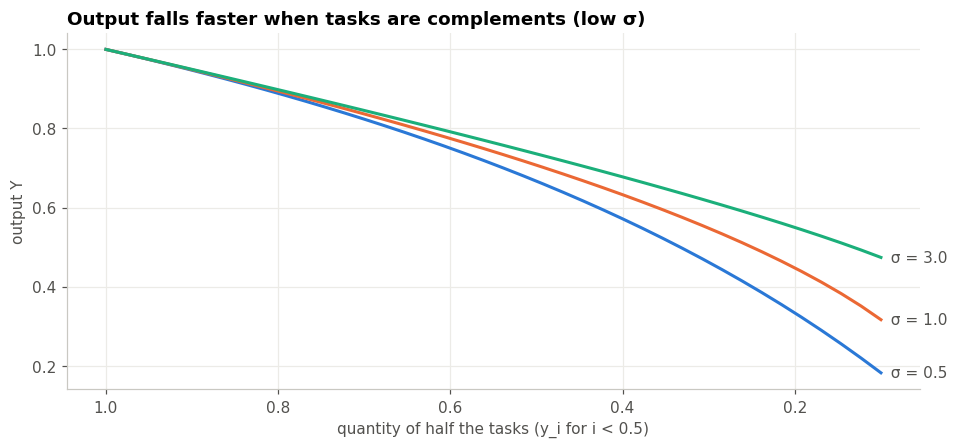

Using σ = 0.8 (tasks are mostly complements)


In [9]:
def ces_output(y_func, sigma, a=0.0, b=1.0):
    # Y = (∫ y_i^((σ-1)/σ) di)^(σ/(σ-1))
    if abs(sigma - 1) < 1e-9:   # Cobb-Douglas limit
        return np.exp(integrate.quad(lambda i: np.log(y_func(i)), a, b)[0])
    r = (sigma - 1) / sigma
    return integrate.quad(lambda i: y_func(i) ** r, a, b)[0] ** (1 / r)

shock = np.linspace(1, 0.1, 40)   # quantity of tasks in [0, 0.5] falls from 1 to 0.1
fig, ax = plt.subplots()
for s, col in [(0.5, BLUE), (1.0, ORANGE), (3.0, AQUA)]:
    Y = [ces_output(lambda i, v=v: v if i < 0.5 else 1.0, s) for v in shock]
    ax.plot(shock, Y, color=col)
    ax.text(shock[-1], Y[-1], f"  σ = {s}", va="center", color=INK)
ax.invert_xaxis(); ax.set_xlabel("quantity of half the tasks (y_i for i < 0.5)"); ax.set_ylabel("output Y")
ax.set_title("Output falls faster when tasks are complements (low σ)", loc="left")
plt.show()
print(f"Using σ = {P['sigma']} (tasks are mostly complements)")

---
## Step 3: Task displacement to AI  (who does task $i$: human or AI?)

**Labour cost of task $i$:**  $e(i) = \dfrac{W}{\gamma(i)}$, where $\gamma(i)$ is human productivity in task $i$ (continuous and increasing, so humans have the edge on higher-$i$ tasks). We use $\gamma(i)=e^{k i}$.

**AI cost of task $i$:**  $c_A$ (the same for all automatable tasks; the notes hold it constant within a year).

**The firm picks the cheaper option:**
$$P(i)=\begin{cases}\min\{c_A,\;W/\gamma(i)\} & i\le I\\ W/\gamma(i) & i>I\end{cases}$$

- $I$ = **technological** threshold: tasks $i\le I$ *can* be automated
- $\bar I$ = **price** threshold where labour cost equals AI cost: $\dfrac{W}{\gamma(\bar I)}=c_A \Rightarrow \gamma(\bar I)=\dfrac{W}{c_A}$ (AR18, eq. 6)
- $I^*=\min\{I,\bar I\}$ = tasks actually done by AI in equilibrium

If $I<\bar I$, automation is **limited by technology**. If $I\ge\bar I$, automation is **limited by price**.

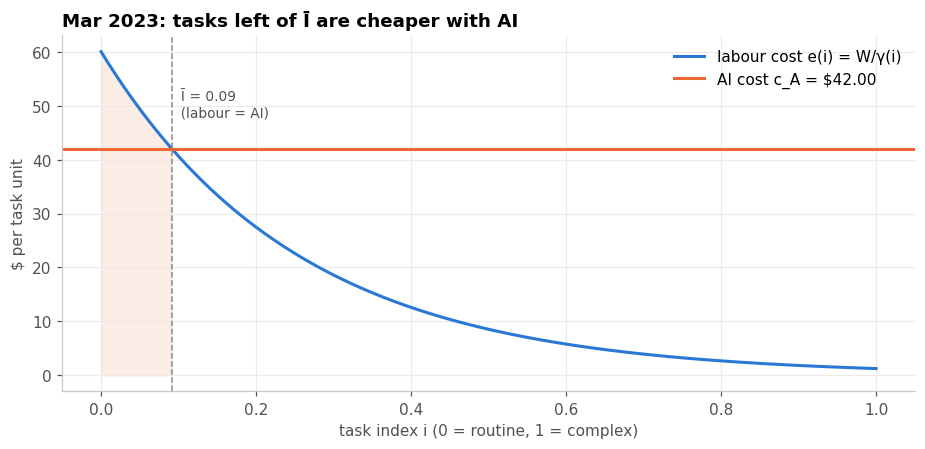

In [10]:
W_hour = P["W_tech"] / P["hours"]          # wage per task unit (1 task unit = 1 hour at γ = 1)
gamma = lambda i: np.exp(P["k_gamma"] * i)

def I_bar(cA):
    # γ(Ī) = W / c_A  →  Ī = ln(W / c_A) / k, clipped to [0, 1]
    return np.clip(np.log(W_hour / cA) / P["k_gamma"], 0, 1)

def I_star(I_tech, cA):
    return np.minimum(I_tech, I_bar(cA))

# Picture for one date: March 2023, scenario A
cA_2023 = c_A("2023-03-01", "A")
i = np.linspace(0, 1, 400)
fig, ax = plt.subplots()
ax.plot(i, W_hour / gamma(i), color=BLUE, label="labour cost e(i) = W/γ(i)")
ax.axhline(cA_2023, color=ORANGE, label=f"AI cost c_A = ${cA_2023:,.2f}")
ax.axvline(I_bar(cA_2023), color=GRAY, ls="--", lw=1)
ax.text(I_bar(cA_2023), W_hour * 0.8, f"  Ī = {I_bar(cA_2023):.2f}\n  (labour = AI)", fontsize=9, color=INK)
ax.fill_between(i, 0, W_hour / gamma(i), where=i <= I_bar(cA_2023), color=ORANGE, alpha=0.12)
ax.set_xlabel("task index i (0 = routine, 1 = complex)"); ax.set_ylabel("$ per task unit")
ax.set_title("Mar 2023: tasks left of Ī are cheaper with AI", loc="left"); ax.legend()
plt.show()

**How Ī moves over time.** We need a path for the technological frontier $I(t)$. We let it grow linearly, $I(t)=I_0+g_I\cdot t$, and in Step 4 we **calibrate $g_I$ to the observed fall in tech employment**. Here is the price threshold $\bar I(t)$ under each token-cost scenario:

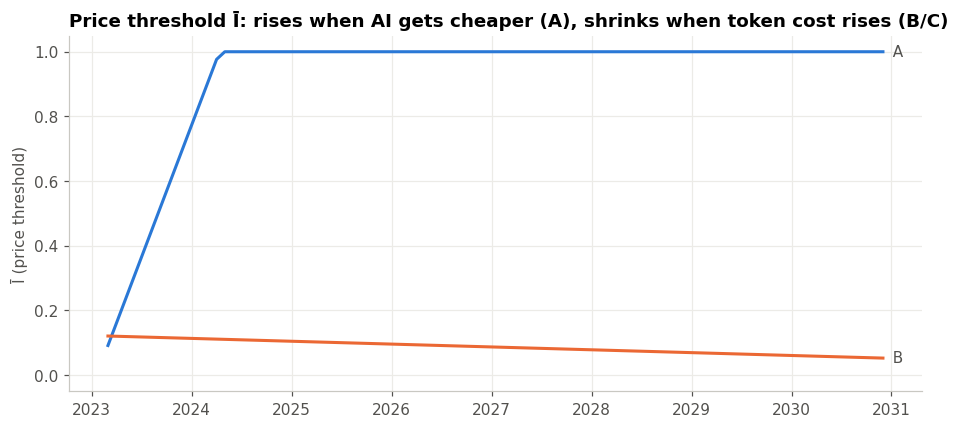

In [11]:
fig, ax = plt.subplots()
for s, col in zip("ABC", [BLUE, ORANGE, AQUA]):
    if s == "C":   # C has the same c_A path as B
        continue
    ib = I_bar(cost_paths[s])
    ax.plot(dates, ib, color=col)
    ax.text(dates[-1], ib.iloc[-1], f"  {s}", color=INK, va="center")
ax.set_ylim(-0.05, 1.05); ax.set_ylabel("Ī (price threshold)")
ax.set_title("Price threshold Ī: rises when AI gets cheaper (A), shrinks when token cost rises (B/C)", loc="left")
plt.show()

---
## Step 4: Junior–mid tech worker displacement

### 4.1 Employment from the task model

The labour needed for human task $i$ is $l(i)=Y\,W^{-\sigma}\gamma(i)^{\sigma-1}$. Integrating over the tasks humans still do gives aggregate tech labour demand:

$$L = Y\,W^{-\sigma}\int_{I^*}^{N}\gamma(i)^{\sigma-1}\,di$$

Holding $Y$ and $W$ fixed, employment relative to a base date is

$$\frac{L(t)}{L(t_0)}=\frac{\int_{I^*(t)}^{1}\gamma^{\sigma-1}di}{\int_{I^*(t_0)}^{1}\gamma^{\sigma-1}di}$$

We calibrate the growth of the tech frontier $g_I$ so the model fits the **observed** fall in tech employment (CES6054150001) since the early-2023 peak. Only the exposed junior–mid share (`exposed_share`) is affected by the model; senior roles are held constant.

In [12]:
def labour_integral(Istar):
    s = P["sigma"]
    return integrate.quad(lambda i: gamma(i) ** (s - 1), Istar, 1)[0]

obs = macro.loc[peak_date:, "tech_emp"]
t_obs = (obs.index - peak_date).days / 365.25
I0 = 0.05   # share of junior-mid tasks already automated at the peak

def model_emp(g_I, idx, scenario="A", L0=obs.iloc[0]):
    yrs = (idx - peak_date).days / 365.25
    Is = I_star(I0 + g_I * yrs, c_A(idx, scenario))
    rel = np.array([labour_integral(x) for x in Is]) / labour_integral(I_star(I0, c_A(peak_date, scenario)))
    return L0 * (1 - P["exposed_share"]) + L0 * P["exposed_share"] * rel

res = optimize.minimize_scalar(lambda g: ((model_emp(g, obs.index) - obs.values) ** 2).sum(),
                               bounds=(0, 0.5), method="bounded")
g_I = res.x
fit = model_emp(g_I, obs.index)
rmse = np.sqrt(np.mean((fit - obs.values) ** 2))
print(f"Calibrated technology frontier growth g_I = {g_I:.4f} per year   (RMSE = {rmse:.1f}k jobs)")
print(f"I*(Aug 2026) = {I0 + g_I * t_obs[-1]:.3f}: the share of junior-mid tasks now done by AI")

Calibrated technology frontier growth g_I = 0.0251 per year   (RMSE = 5.5k jobs)
I*(Aug 2026) = 0.136: the share of junior-mid tasks now done by AI


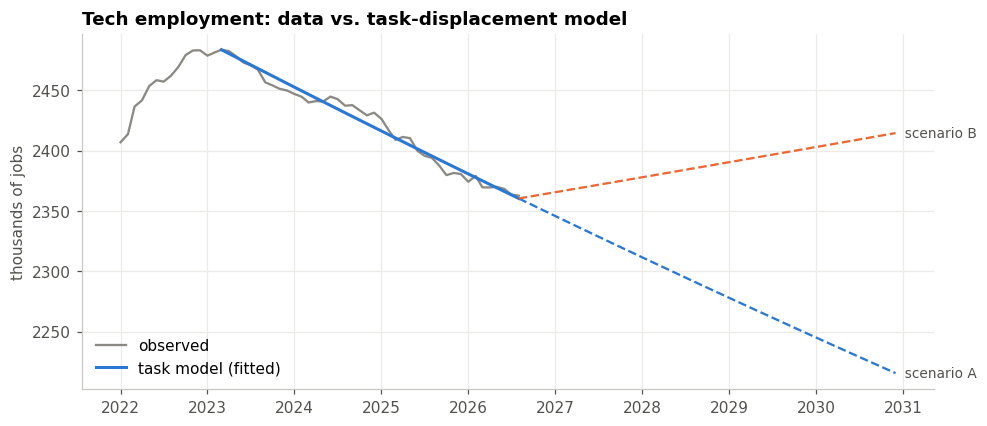

In [13]:
fig, ax = plt.subplots()
ax.plot(macro.index, macro["tech_emp"], color=GRAY, lw=1.5, label="observed")
ax.plot(obs.index, fit, color=BLUE, label="task model (fitted)")
future = pd.date_range(obs.index[-1], "2030-12-01", freq="MS")
for s, col in zip("AB", [BLUE, ORANGE]):
    # project from the last fitted value: L(t) = L_fit(Aug-26) × [model(t) / model(Aug-26)] for that scenario
    base = model_emp(g_I, future, s)
    proj = fit[-1] * base / base[0]
    ax.plot(future, proj, color=col, ls="--", lw=1.5)
    ax.text(future[-1], proj[-1], f"  scenario {s}", color=INK, va="center", fontsize=9)
ax.set_ylabel("thousands of jobs")
ax.set_title("Tech employment: data vs. task-displacement model", loc="left"); ax.legend(loc="lower left")
plt.show()

**Reading it.** In scenario A (cheap AI) $\bar I$ is close to 1, so automation is **limited by technology**: $I^*=I(t)$ and jobs keep falling as capability grows. In scenario B (rising cost per task) $\bar I$ falls below the frontier, automation becomes **limited by price**, and the task model says some tasks return to humans, so employment recovers.

The notes argue this return does **not** happen in practice: firms already committed to AI respond to higher token bills by *cutting more staff* (**"more cost minimisation → more employee termination"**). The notes' supervisor equation captures that channel, and it is next.

### 4.2 The supervision channel: $L=\dfrac{x}{c_A+e_s}\cdot\dfrac{1}{g_s}$

*"Firms are giving tasks to AI and firing humans, so now one human needs to supervise many tasks at once."*

- $x$ = firm spending on the task bundle (fixed budget, cost minimisation)
- $c_A+e_s$ = cost of one AI-done task: tokens plus human supervision cost $e_s$
- $g_s$ = number of tasks one human supervises (span)

Rising $c_A$ (scenario B) or a wider span $g_s$ (scenario C) both push $L$ down. We also track the **wage share** of task spending, $S_W = WL/x$.

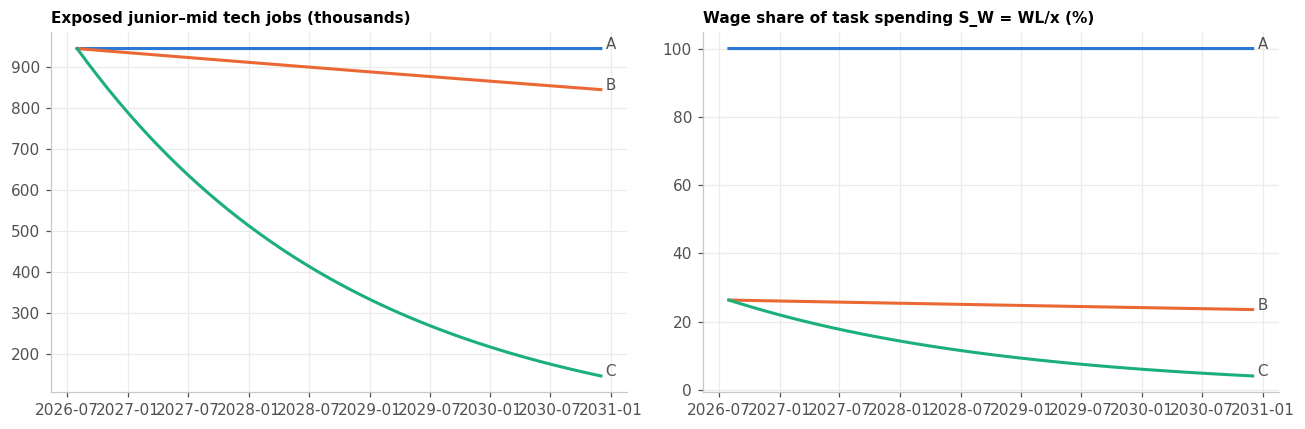

,A,B,C
Aug 2026,945.100,945.100,945.100
Aug 2027,945.100,921.300,614.400
Aug 2028,945.100,897.900,398.800
Aug 2029,945.100,874.900,259.200
Aug 2030,945.100,852.300,168.400


In [14]:
def supervisors(date, scenario, x, e_s, g_s0):
    yrs = np.maximum((pd.to_datetime(date) - pd.Timestamp("2026-08-01")).days / 365.25, 0)
    g_s = g_s0 * SPAN_GROWTH[scenario] ** np.asarray(yrs)
    return x / ((c_A(date, scenario) + e_s) * g_s)

# Calibrate to Aug-2026: exposed workers L0, each supervises g_s0 task-units per month
L_exposed0 = macro["tech_emp"].iloc[-1] * 1e3 * P["exposed_share"]
g_s0 = 4 * P["hours"]                       # a supervisor oversees ~4× the output of one junior
e_s = W_hour / 4                            # supervision labour cost per task unit
# budget x that matches today's L in each scenario (cost minimisation: x then stays fixed)
x0 = {s: L_exposed0 * g_s0 * (c_A("2026-08-01", s) + e_s) for s in "ABC"}

proj_dates = pd.date_range("2026-08-01", "2030-12-01", freq="MS")
sup = pd.DataFrame({s: supervisors(proj_dates, s, x0[s], e_s, g_s0) for s in "ABC"}, index=proj_dates)
S_W = pd.DataFrame({s: P["W_tech"] * sup[s] / x0[s] for s in "ABC"})

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for s, col in zip("ABC", [BLUE, ORANGE, AQUA]):
    ax[0].plot(sup.index, sup[s] / 1e3, color=col); ax[0].text(sup.index[-1], sup[s].iloc[-1] / 1e3, f" {s}", color=INK)
    ax[1].plot(S_W.index, S_W[s] * 100, color=col); ax[1].text(S_W.index[-1], S_W[s].iloc[-1] * 100, f" {s}", color=INK)
ax[0].set_title("Exposed junior–mid tech jobs (thousands)", loc="left", fontsize=10)
ax[1].set_title("Wage share of task spending S_W = WL/x (%)", loc="left", fontsize=10)
plt.tight_layout(); plt.show()
sup[sup.index.month == 8].div(1e3).round(1).rename(index=lambda d: f"Aug {d.year}")

### 4.3 Displaced workers $L_{disp}$ (from the data)

We measure displacement two ways:
1. **Peak-to-now:** jobs lost since the peak (a lower bound).
2. **Versus trend:** jobs lost against the 2022 growth trend continued forward (an upper bound; the 2022 trend was a post-COVID hiring boom, so it overstates).

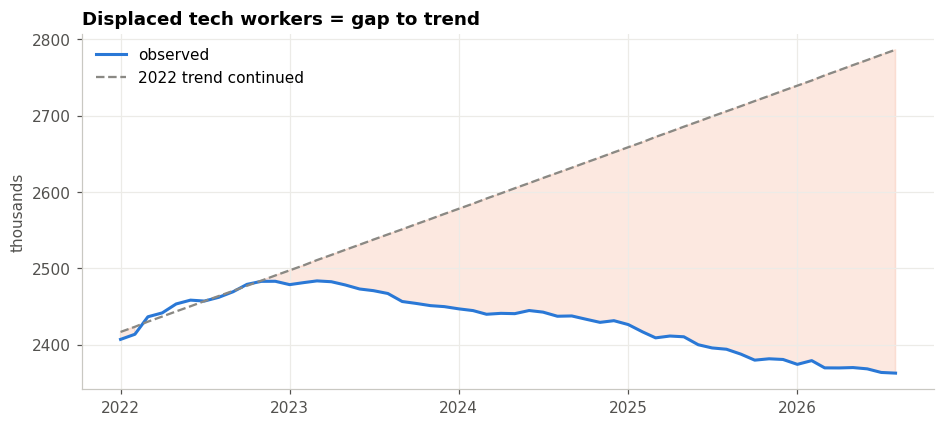

L_disp  peak-to-now (low):    120,800 workers
L_disp    vs trend (high):    423,527 workers


In [15]:
pre = macro.loc[:"2022-12-01", "tech_emp"]
tt = np.arange(len(pre))
slope, intercept = np.polyfit(tt, pre.values, 1)
trend = pd.Series(intercept + slope * np.arange(len(macro)), index=macro.index)

L_disp_peak = (macro["tech_emp"].max() - macro["tech_emp"]).clip(lower=0).where(macro.index >= peak_date, 0)
L_disp_trend = (trend - macro["tech_emp"]).clip(lower=0)

fig, ax = plt.subplots()
ax.plot(macro.index, macro["tech_emp"], color=BLUE, label="observed")
ax.plot(macro.index, trend, color=GRAY, ls="--", lw=1.5, label="2022 trend continued")
ax.fill_between(macro.index, macro["tech_emp"], trend, where=trend > macro["tech_emp"], color=ORANGE, alpha=0.15)
ax.set_ylabel("thousands"); ax.set_title("Displaced tech workers = gap to trend", loc="left"); ax.legend()
plt.show()

L_disp = {"peak-to-now (low)": L_disp_peak.iloc[-1] * 1e3, "vs trend (high)": L_disp_trend.iloc[-1] * 1e3}
for k, v in L_disp.items():
    print(f"L_disp {k:>18}: {v:>10,.0f} workers")

---
## Step 5: Buffer phase: look for a job of the same type, savings fall to almost 0

After firing at date $t_d$, the search duration is $\tau=t-t_d$. While searching, the worker keeps spending about the same, $\bar c$, and receives only $z$ (benefits, severance, freelancing):

$$\frac{dm(\tau)}{d\tau}=z-\bar c,\qquad m(0)=s_r W\;\Rightarrow\; m(\tau)=s_rW+(z-\bar c)\,\tau$$

Savings run out ($m(T_0)=0$) at

$$T_0=\frac{s_r W}{\bar c - z}$$

**Data mapping**
- $s_r$ = personal saving rate at the firing date (PSAVERT)
- $W$ = pre-fire monthly wage; the stock $m(0)$ is $s_r W$ times `save_months` (set it to 1 for the literal formula)
- $\bar c=(1-s_r)W$, i.e. pre-fire spending that "stays more or less the same"

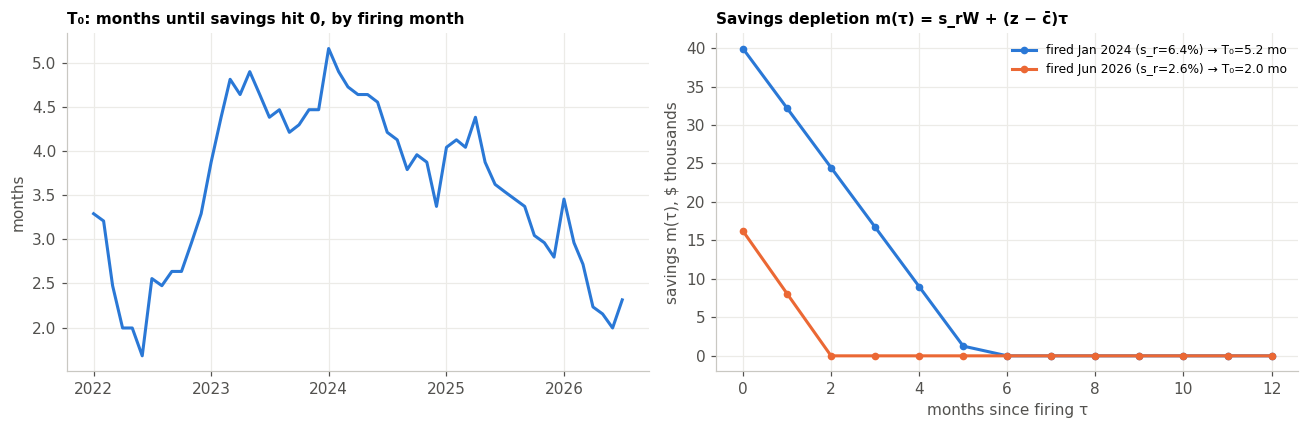

Runway for a worker fired at the saving-rate peak (Jan 2024): 5.2 months
Runway for a worker fired in Jul 2026: 2.3 months


In [16]:
def runway(s_r, W=P["W_tech"], z=P["z"], months=P["save_months"]):
    m0 = s_r * W * months
    c_bar = (1 - s_r) * W
    return m0, c_bar, m0 / (c_bar - z)

sr = macro["save_rate"].dropna() / 100
T0 = pd.Series([runway(s)[2] for s in sr], index=sr.index)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(T0.index, T0, color=BLUE)
ax[0].set_title("T₀: months until savings hit 0, by firing month", loc="left", fontsize=10)
ax[0].set_ylabel("months")
ax[0].xaxis.set_major_locator(mdates.YearLocator()); ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

tau = np.arange(0, 13)
for d, col in [("2024-01-01", BLUE), ("2026-06-01", ORANGE)]:
    m0, cbar, t0 = runway(sr[d])
    m = np.maximum(m0 + (P["z"] - cbar) * tau, 0)
    ax[1].plot(tau, m / 1e3, color=col, marker="o", ms=4,
               label=f"fired {pd.Timestamp(d):%b %Y} (s_r={sr[d]:.1%}) → T₀={t0:.1f} mo")
ax[1].legend(fontsize=8)
ax[1].set_xlabel("months since firing τ"); ax[1].set_ylabel("savings m(τ), $ thousands")
ax[1].set_title("Savings depletion m(τ) = s_rW + (z − c̄)τ", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

print(f"Runway for a worker fired at the saving-rate peak ({sr.idxmax():%b %Y}): {T0.max():.1f} months")
print(f"Runway for a worker fired in {sr.index[-1]:%b %Y}: {T0.iloc[-1]:.1f} months")

**Checking against the search series.** If displaced tech workers stay in the buffer phase, the number of people *searching but not counted in the labour force* should rise as tech jobs fall. We check the correlation between cumulative tech displacement and the search pool, in levels and over 12-month changes (levels alone can show a spurious trend correlation).

Correlation (levels):         0.90
Correlation (12-mo changes):  0.82


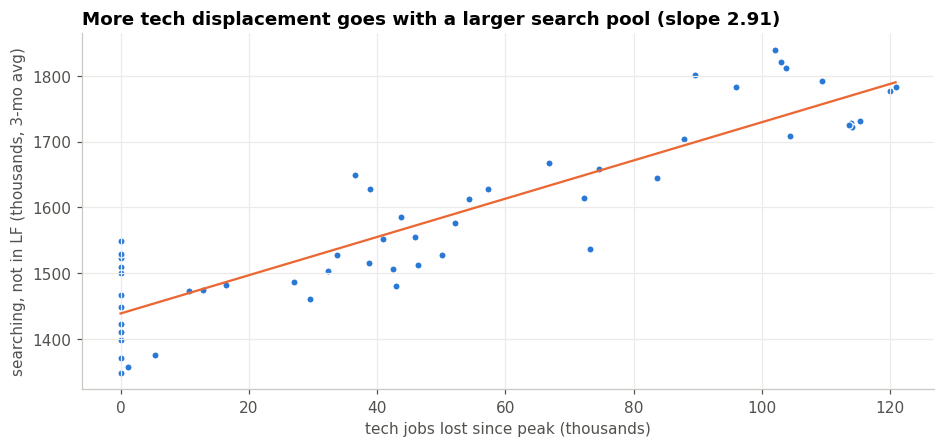

In [17]:
chk = pd.DataFrame({"L_disp": L_disp_peak, "searching": macro["searching"].rolling(3).mean()}).dropna()
print(f"Correlation (levels):         {chk.corr().iloc[0, 1]:.2f}")
print(f"Correlation (12-mo changes):  {chk.diff(12).dropna().corr().iloc[0, 1]:.2f}")

fig, ax = plt.subplots()
ax.scatter(chk["L_disp"], chk["searching"], color=BLUE, s=22, edgecolor="white", linewidth=0.8)
b1, b0 = np.polyfit(chk["L_disp"], chk["searching"], 1)
xs = np.linspace(chk["L_disp"].min(), chk["L_disp"].max(), 10)
ax.plot(xs, b0 + b1 * xs, color=ORANGE, lw=1.5)
ax.set_xlabel("tech jobs lost since peak (thousands)"); ax.set_ylabel("searching, not in LF (thousands, 3-mo avg)")
ax.set_title(f"More tech displacement goes with a larger search pool (slope {b1:.2f})", loc="left")
plt.show()

> The slope compares two aggregates. The search pool includes all occupations, so this is consistent with the buffer-phase story but does not prove that the searchers are tech workers.

**Savings rate and real consumption.** The flowchart says spending stays about the same while savings fall. At the national level, real consumption kept growing while the saving rate fell from 6.4% to ~3%: households are keeping spending up by saving less.

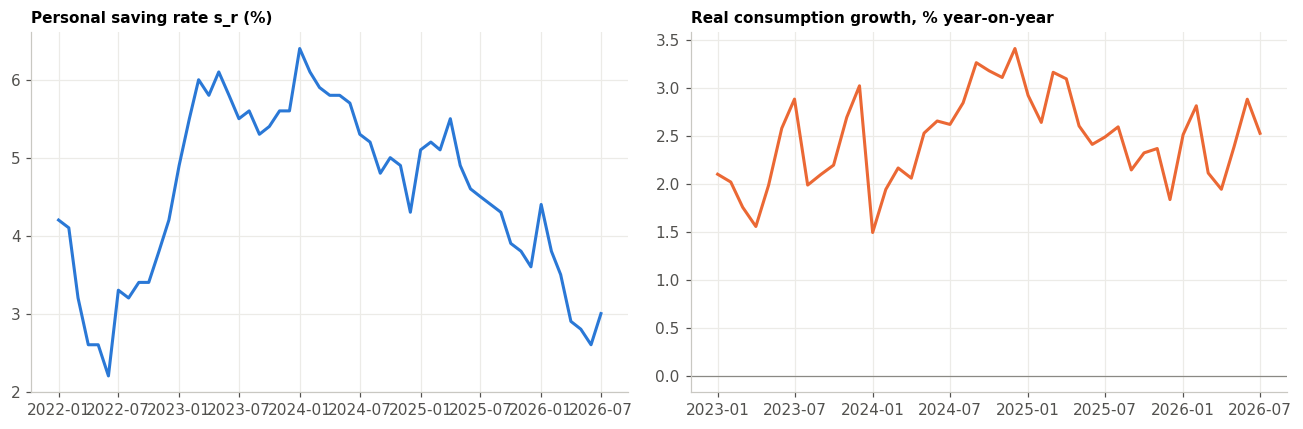

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(macro.index, macro["save_rate"], color=BLUE)
ax[0].set_title("Personal saving rate s_r (%)", loc="left", fontsize=10)
g = macro["real_pce"].pct_change(12, fill_method=None) * 100
ax[1].plot(g.index, g, color=ORANGE); ax[1].axhline(0, color=GRAY, lw=0.8)
ax[1].set_title("Real consumption growth, % year-on-year", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

---
## Step 6: Switch to a lower-paying job / leave the tech industry

Best case assumed in the notes: after using all savings, the worker gets a **non-tech job**. Almost no one returns to their earlier tech job. The wage gap is

$$\Delta W = W_{Tech}-W_{Service} > 0$$

and the fall in private consumer demand from displaced workers moving across sectors is

$$\Delta C_{fired} = -c_L\,L_{disp}\,(W_{Tech}-W_{Service})$$

In [19]:
dW = P["W_tech"] - P["W_service"]
print(f"Wage gap ΔW = ${dW:,.0f} per month ({dW / P['W_tech']:.0%} of the tech wage)\n")

rows = []
for k, Ld in L_disp.items():
    dC_month = -P["c_L"] * Ld * dW
    rows.append({"L_disp measure": k, "L_disp": Ld,
                 "ΔC_fired $bn / month": dC_month / 1e9,
                 "ΔC_fired $bn / year": dC_month * 12 / 1e9,
                 "% of annual PCE": dC_month * 12 / 1e9 / macro["pce"].dropna().iloc[-1] * 100})
dC_table = pd.DataFrame(rows).set_index("L_disp measure")
dC_table

Wage gap ΔW = $6,600 per month (63% of the tech wage)



,L_disp,ΔC_fired $bn / month,ΔC_fired $bn / year,% of annual PCE
L_disp measure,,,,
peak-to-now (low),"120,800.000",-0.638,-7.654,-0.034
vs trend (high),"423,526.923",-2.236,-26.835,-0.121


---
## Step 7: National economy: who gets the income?

$$Y_{national}=\underbrace{W_{Tech}L_{Tech}+W_{Service}L_S}_{Y_L}+\underbrace{\text{Corporate}+p_T\,q\,Y_A}_{Y_K\text{ (capital / token income)}}$$

$$S_L=\frac{Y_L}{Y},\qquad S_K=\frac{Y_K}{Y}=1-S_L$$

**Income redistribution** when $L_{disp}$ workers move from tech to service jobs:

$$\Delta Y_L=-L_{disp}(W_{Tech}-W_{Service})<0,\qquad \Delta Y_K=\Delta Y-\Delta Y_L=\Delta Y+L_{disp}(W_{Tech}-W_{Service})>0$$

National income shifts away from labour toward token revenue.

We scale national income from PCE: $Y \approx PCE / 0.68$ (PCE is about 68% of US national income), with an initial labour share of 0.60. $\Delta Y$ is the net output gain from AI. We set it equal to the firms' wage savings minus their token bill (tokens replace the displaced workers' task units).

In [20]:
Y_ann = macro["pce"].dropna().iloc[-1] * 1e9 / P["pce_share"]   # annual national income, $
Y_L0, Y_K0 = P["labour_share0"] * Y_ann, (1 - P["labour_share0"]) * Y_ann

def redistribution(Ld, cA_unit):
    dY_L = -Ld * dW * 12                                  # annual labour-income loss
    token_bill = Ld * P["hours"] * cA_unit * 12           # AI cost to replace their task units
    dY = Ld * P["W_tech"] * 12 - token_bill          # net gain = wage bill saved − token bill
    dY_K = dY - dY_L
    S_L1 = (Y_L0 + dY_L) / (Y_ann + dY)
    return dict(dY=dY, dY_L=dY_L, dY_K=dY_K, S_L0=P["labour_share0"], S_L1=S_L1, S_K1=1 - S_L1)

red = pd.DataFrame({k: redistribution(Ld, c_A("2026-08-01", "A")) for k, Ld in L_disp.items()}).T
show = red.copy()
for c in ["dY", "dY_L", "dY_K"]:
    show[c] = show[c] / 1e9
show.rename(columns={"dY": "ΔY $bn", "dY_L": "ΔY_L $bn", "dY_K": "ΔY_K $bn"})

,ΔY $bn,ΔY_L $bn,ΔY_K $bn,S_L0,S_L1,S_K1
peak-to-now (low),15.076,-9.567,24.643,0.600,0.599,0.401
vs trend (high),52.855,-33.543,86.399,0.600,0.598,0.402


---
## Step 8: Fewer consumers → less income for other industries

**Consumption demand** splits by who holds the income:

$$C=c_LY_L+c_KY_K=Y\,(c_LS_L+c_KS_K),\qquad c_L\gg c_K$$

**Change in consumption:** using $\Delta Y_K=\Delta Y-\Delta Y_L$,

$$\Delta C=c_L\Delta Y_L+c_K\Delta Y_K=(c_L-c_K)\Delta Y_L+c_K\Delta Y$$

**Consumer demand shrinks** ($\Delta C<0$) when

$$\frac{\Delta Y}{|\Delta Y_L|}<\frac{c_L-c_K}{c_K}$$

That is, when AI's output gain is small relative to the labour income it removes.

**Keynesian multiplier** across non-AI businesses (organic food, clothing, even healthcare):

$$\Delta AD=\frac{1}{1-c_L}\,\Delta C$$

In [21]:
threshold = (P["c_L"] - P["c_K"]) / P["c_K"]
mult = 1 / (1 - P["c_L"])
print(f"Demand shrinks if ΔY/|ΔY_L| < (c_L − c_K)/c_K = {threshold:.2f}")
print(f"Multiplier 1/(1 − c_L) = {mult:.1f}\n")

out = red.assign(ratio=red.dY / red.dY_L.abs(),
                 dC=(P["c_L"] - P["c_K"]) * red.dY_L + P["c_K"] * red.dY)
out["dAD"] = mult * out.dC
out["shrinks?"] = out.ratio < threshold
out["ΔAD % of PCE"] = out.dAD / (macro["pce"].dropna().iloc[-1] * 1e9) * 100
out[["ratio", "shrinks?"]].join((out[["dC", "dAD"]] / 1e9).rename(columns={"dC": "ΔC $bn/yr", "dAD": "ΔAD $bn/yr"})).join(out[["ΔAD % of PCE"]])

Demand shrinks if ΔY/|ΔY_L| < (c_L − c_K)/c_K = 1.67
Multiplier 1/(1 − c_L) = 5.0



,ratio,shrinks?,ΔC $bn/yr,ΔAD $bn/yr,ΔAD % of PCE
peak-to-now (low),1.576,True,-0.261,-1.305,-0.006
vs trend (high),1.576,True,-0.915,-4.575,-0.021


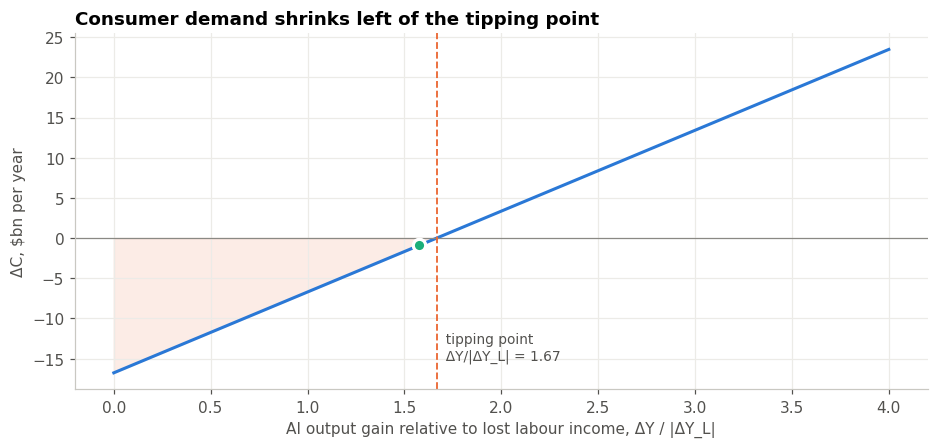

In [22]:
# Where is the tipping point? ΔC as a function of the AI output gain ΔY
Ld = L_disp["vs trend (high)"]
dY_L = -Ld * dW * 12
ratios = np.linspace(0, 4, 200)
dC_curve = (P["c_L"] - P["c_K"]) * dY_L + P["c_K"] * ratios * abs(dY_L)

fig, ax = plt.subplots()
ax.plot(ratios, dC_curve / 1e9, color=BLUE)
ax.axhline(0, color=GRAY, lw=0.8); ax.axvline(threshold, color=ORANGE, ls="--", lw=1.2)
ax.text(threshold, dC_curve.min() / 1e9 * 0.9, f"  tipping point\n  ΔY/|ΔY_L| = {threshold:.2f}", color=INK, fontsize=9)
ax.fill_between(ratios, dC_curve / 1e9, 0, where=dC_curve < 0, color=ORANGE, alpha=0.12)
for k, r in out.ratio.items():
    ax.plot(r, ((P["c_L"] - P["c_K"]) * dY_L + P["c_K"] * r * abs(dY_L)) / 1e9, "o", color=AQUA, ms=8,
            markeredgecolor="white", markeredgewidth=2)
ax.set_xlabel("AI output gain relative to lost labour income, ΔY / |ΔY_L|"); ax.set_ylabel("ΔC, $bn per year")
ax.set_title("Consumer demand shrinks left of the tipping point", loc="left")
plt.show()

---
## Step 9: The token-cost feedback loop (all boxes together)

*"Token price increases → more employees get fired. Almost no employee goes back to the earlier job."*

This simulation runs the whole flowchart month by month from Aug 2026 to Dec 2030:

1. **Token cost** $c_A(t)$ follows scenario A, B or C (Step 1).
2. **Cost minimisation:** exposed tech employment $L(t)=\dfrac{x(t)}{(c_A+e_s)\,g_s}$ (Step 4.2). Jobs lost are never re-filled (**ratchet**: $L(t)\le L(t-1)$).
3. Each month's fired cohort enters the **buffer phase** with runway $T_0$ set by the current saving rate (Step 5). The saving rate follows its 2024–2026 trend down to a 1% floor.
4. At $T_0$ the cohort **switches to a service job**, and its consumption falls by $c_L\,\Delta W$ per worker (Step 6).
5. The **multiplier** turns that into lost aggregate demand (Step 8).
6. **Feedback:** lower demand cuts firm revenue and so the tech budget $x(t)$, with elasticity `phi`. This closes the spiral.

In [23]:
def simulate(scenario, phi=1.0, months=None):
    idx = pd.date_range("2026-08-01", "2030-12-01", freq="MS") if months is None else months
    # saving-rate path: continue the 2024-2026 linear trend, floor at 1%
    hist = sr.loc["2024-01-01":]
    b1, b0 = np.polyfit(np.arange(len(hist)), hist.values, 1)
    sr_path = np.maximum(b0 + b1 * (len(hist) - 1 + np.arange(len(idx))), 0.01)

    pce_month = macro["pce"].dropna().iloc[-1] * 1e9 / 12
    L = np.zeros(len(idx)); L[0] = L_exposed0
    fired = np.zeros(len(idx)); dC = np.zeros(len(idx)); in_buffer = np.zeros(len(idx))
    cohorts = []                                   # (month fired, size, runway T0)
    x = x0[scenario]
    for t in range(1, len(idx)):
        yrs = t / 12
        g_s = g_s0 * SPAN_GROWTH[scenario] ** yrs
        target = x / ((c_A(idx[t], scenario) + e_s) * g_s)
        L[t] = min(L[t - 1], target)               # ratchet: no rehiring
        fired[t] = L[t - 1] - L[t]
        cohorts.append((t, fired[t], runway(sr_path[t])[2]))
        # cohorts that have used up their savings switch to service jobs → consumption loss
        switched = sum(n for (t0, n, T) in cohorts if t - t0 >= T)
        in_buffer[t] = sum(n for (t0, n, T) in cohorts if t - t0 < T)
        dC[t] = -P["c_L"] * switched * dW
        dAD = mult * dC[t]
        x = x0[scenario] * (1 + phi * dAD / pce_month)       # feedback: lost demand → smaller tech budget
    return pd.DataFrame({"L_exposed": L, "fired": fired, "in_buffer": in_buffer, "switched": L[0] - L - in_buffer,
                         "dC_month": dC, "dAD_month": mult * dC, "save_rate": sr_path}, index=idx)

sims = {s: simulate(s) for s in "ABC"}
summary = pd.DataFrame({s: {"exposed jobs lost by 2030 (k)": (d.L_exposed.iloc[0] - d.L_exposed.iloc[-1]) / 1e3,
                            "in buffer phase Dec-2030 (k)": d.in_buffer.iloc[-1] / 1e3,
                            "switched to service (k)": d.switched.iloc[-1] / 1e3,
                            "ΔC Dec-2030, $bn/yr": d.dC_month.iloc[-1] * 12 / 1e9,
                            "ΔAD Dec-2030, $bn/yr": d.dAD_month.iloc[-1] * 12 / 1e9,
                            "ΔAD, % of PCE": d.dAD_month.iloc[-1] / (macro['pce'].dropna().iloc[-1] * 1e9 / 12) * 100}
                        for s, d in sims.items()})
summary

,A,B,C
exposed jobs lost by 2030 (k),0.000,101.392,800.931
in buffer phase Dec-2030 (k),0.000,1.849,5.289
switched to service (k),0.000,99.543,795.643
"ΔC Dec-2030, $bn/yr",-0.000,-6.307,-50.412
"ΔAD Dec-2030, $bn/yr",-0.000,-31.535,-252.060
"ΔAD, % of PCE",-0.000,-0.142,-1.133


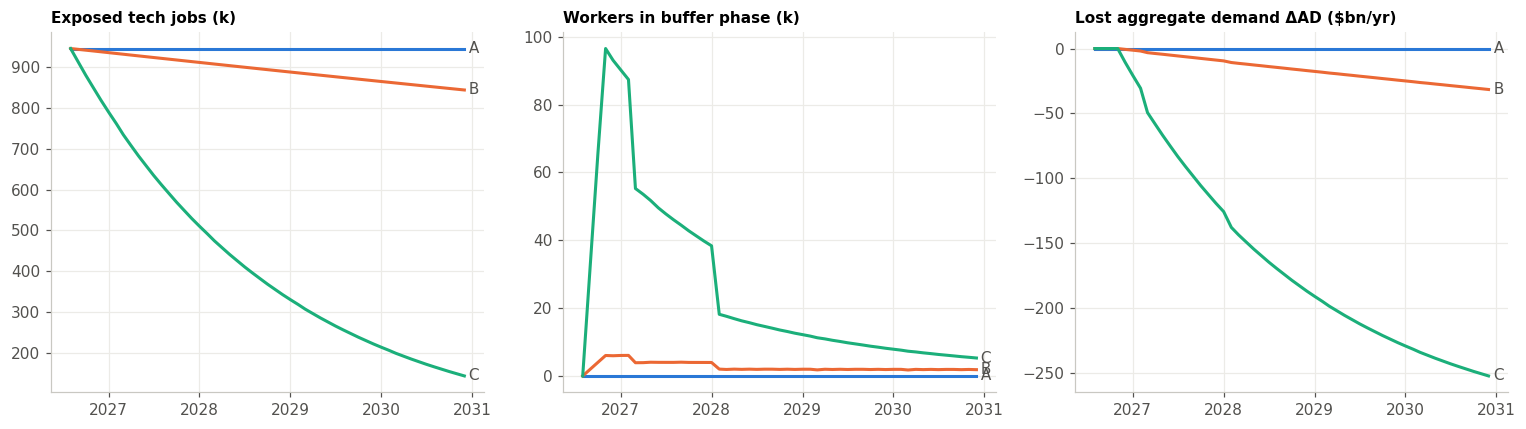

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for s, col in zip("ABC", [BLUE, ORANGE, AQUA]):
    d = sims[s]
    ax[0].plot(d.index, d.L_exposed / 1e3, color=col)
    ax[1].plot(d.index, d.in_buffer / 1e3, color=col)
    ax[2].plot(d.index, d.dAD_month * 12 / 1e9, color=col)
    for a, v in zip(ax, [d.L_exposed / 1e3, d.in_buffer / 1e3, d.dAD_month * 12 / 1e9]):
        a.text(d.index[-1], v.iloc[-1], f" {s}", color=INK, va="center")
ax[0].set_title("Exposed tech jobs (k)", loc="left", fontsize=10)
ax[1].set_title("Workers in buffer phase (k)", loc="left", fontsize=10)
ax[2].set_title("Lost aggregate demand ΔAD ($bn/yr)", loc="left", fontsize=10)
for a in ax: a.xaxis.set_major_locator(mdates.YearLocator()); a.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

### 9.1 How strong must the feedback be to cause a spiral?

The notes end with a *"downward economic spiral, further away from fixed points"*. We sweep the feedback elasticity `phi` (how much tech budgets react to lost demand) in scenario C and look at the job losses.

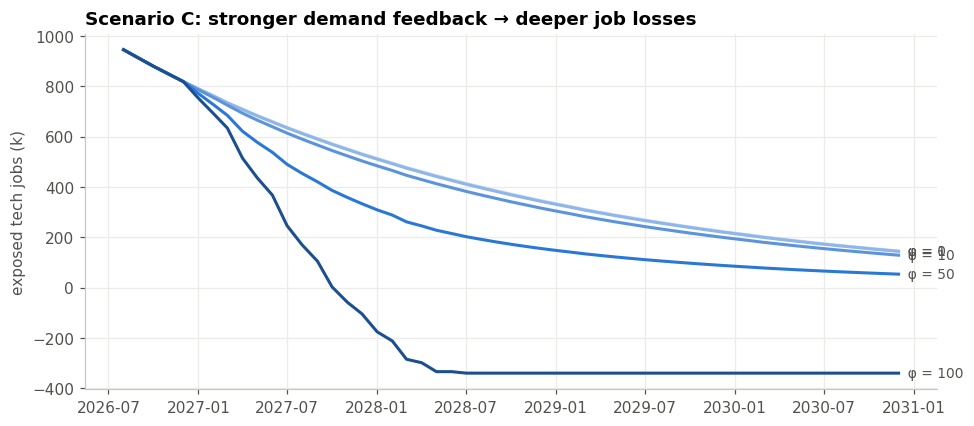

,0,1,10,50,100
jobs lost by Dec-2030 (k),799.291,800.931,816.025,891.324,"1,284.483"


In [25]:
phis = [0, 1, 10, 50, 100]
sweep = pd.DataFrame({phi: simulate("C", phi=phi).L_exposed / 1e3 for phi in phis})
fig, ax = plt.subplots()
shades = ["#c7daf3", "#8fb6e8", "#5b93dd", BLUE, "#1c4f8f"]   # one hue, light → dark = weak → strong feedback
for phi, col in zip(phis, shades):
    ax.plot(sweep.index, sweep[phi], color=col)
    ax.text(sweep.index[-1], sweep[phi].iloc[-1], f"  φ = {phi}", color=INK, va="center", fontsize=9)
ax.set_ylabel("exposed tech jobs (k)")
ax.set_title("Scenario C: stronger demand feedback → deeper job losses", loc="left")
plt.show()
(sweep.iloc[0] - sweep.iloc[-1]).rename("jobs lost by Dec-2030 (k)").to_frame().T

---
## Summary

| Flowchart box | What the data / model shows |
|---|---|
| Firm AI adoption → token cost | Price per token for a fixed capability falls very fast (Step 1). The notes' "token cost increase" holds only if tokens per task $q$ rise faster: $c_A=p_Tq$. |
| Task displacement to AI | With cheap tokens, automation is **technology-limited** ($I^*=I$). The calibrated frontier reproduces the 2023–2026 fall in tech employment (Step 4.1). |
| Junior–mid displacement | Computer-systems-design employment is ~120k below its 2023 peak and further below the 2022 trend (Step 4.3). |
| More cost minimisation → more termination | In the supervision equation, rising $c_A$ or a wider span $g_s$ cuts jobs even with a fixed budget (Step 4.2). |
| Buffer phase, savings → 0 | Falling saving rate → shorter runway $T_0$ for each new cohort (Step 5). The search pool rises together with tech displacement. |
| Switch to a lower-paying job | $\Delta C_{fired}=-c_LL_{disp}\Delta W$ (Step 6). |
| Fewer consumers for other industries | $\Delta C<0$ when $\Delta Y/|\Delta Y_L|<(c_L-c_K)/c_K$; the multiplier $1/(1-c_L)$ amplifies it (Step 8). |
| Feedback loop | The spiral needs rising task cost (B/C) **and** a strong demand feedback (Step 9). |

### Limitations
- **Scale.** The displaced tech workforce is small next to a ~$22T consumer economy, so on its own the model gives a demand loss well under 1% of PCE. A national spiral would need displacement to spread well beyond computer systems design.
- **Assumed parameters.** Wages, $q$, $\sigma$, $c_L$, $c_K$, $z$ and `save_months` are assumptions (Step 0.2). Change them and re-run.
- **Attribution.** The tech employment decline since 2023 also reflects interest rates and post-COVID over-hiring, not just AI. The fitted $g_I$ attributes all of it to AI, so read it as an upper bound.
- **Search series.** LNU05026642 covers all occupations, not only tech workers.
- **Token prices** end in Feb 2025; later values are extrapolated.

### Where to go next
- Add wage data (e.g. FRED `CES6054150003`, average hourly earnings) to replace the wage assumptions.
- Add broader occupation groups to $L_{disp}$ to test the national-scale spiral.
- Estimate $c_L$ and $c_K$ from income-group consumption data instead of assuming them.